In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [25]:
#  imports & setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageOnlyDataset
from src.models import build_vision_backbone
from src.train import train_one_epoch_image, validate_image

main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp2_256_effB1_Freeze_BN_Running_stats")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp2"]
cfg["backbone"] = "efficientnet_b1"
cfg["name"] = "exp2_256_effB1_Freeze_BN_Running_stats"

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


### Image backbone Frozen, Batch Norm Running Stats Not Frozen

In [14]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

# id2idx = {id_: i for i, id_ in enumerate(df["Id"].values)}
start_all = time.time()

for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
        freeze_backbone=True,
        BN_running_state_frozen=False
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp2_256_effB1_Freeze_BN_Running_stats: Fold 1 ===
[TRAIN BATCH 247] preds min=26.0608 max=76.9255 mean=37.3541var=117.4910
[TRAIN BATCH 247] loss=530.0913
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=25.2012 | ValRMSE: 19.8472
[TRAIN BATCH 247] preds min=24.0202 max=68.0596 mean=39.4939var=140.5740
[TRAIN BATCH 247] loss=374.3957
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=16.9803 | ValRMSE: 19.9511
[TRAIN BATCH 247] preds min=21.0769 max=83.3558 mean=37.6246var=231.7331
[TRAIN BATCH 247] loss=264.5169
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=14.5025 | ValRMSE: 20.4488
[TRAIN BATCH 247] preds min=13.5674 max=73.5286 mean=38.1241var=172.0923
[TRAIN BATCH 247] loss=129.3312
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=12.0709 | ValRMSE: 20.6287
[TRAIN BATCH 247] preds min=17.1111 max=76.5515 mean=37.6513var=244.9064
[TRAIN BATCH 247] loss=132.9789
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=10.3186 | ValRMSE: 20.8763
[TRAIN BATCH 247] preds min=16.6492 max=87.8586 mean=41.0005var=392.3529
[TRAIN BATCH 247

In [15]:

import pandas
oof_df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = oof_df[oof_df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 19.8472 (n=1983)
Fold 2 OOF RMSE: 19.3744 (n=1983)
Fold 3 OOF RMSE: 19.0111 (n=1982)
Fold 4 OOF RMSE: 19.1348 (n=1982)
Fold 5 OOF RMSE: 19.7171 (n=1982)


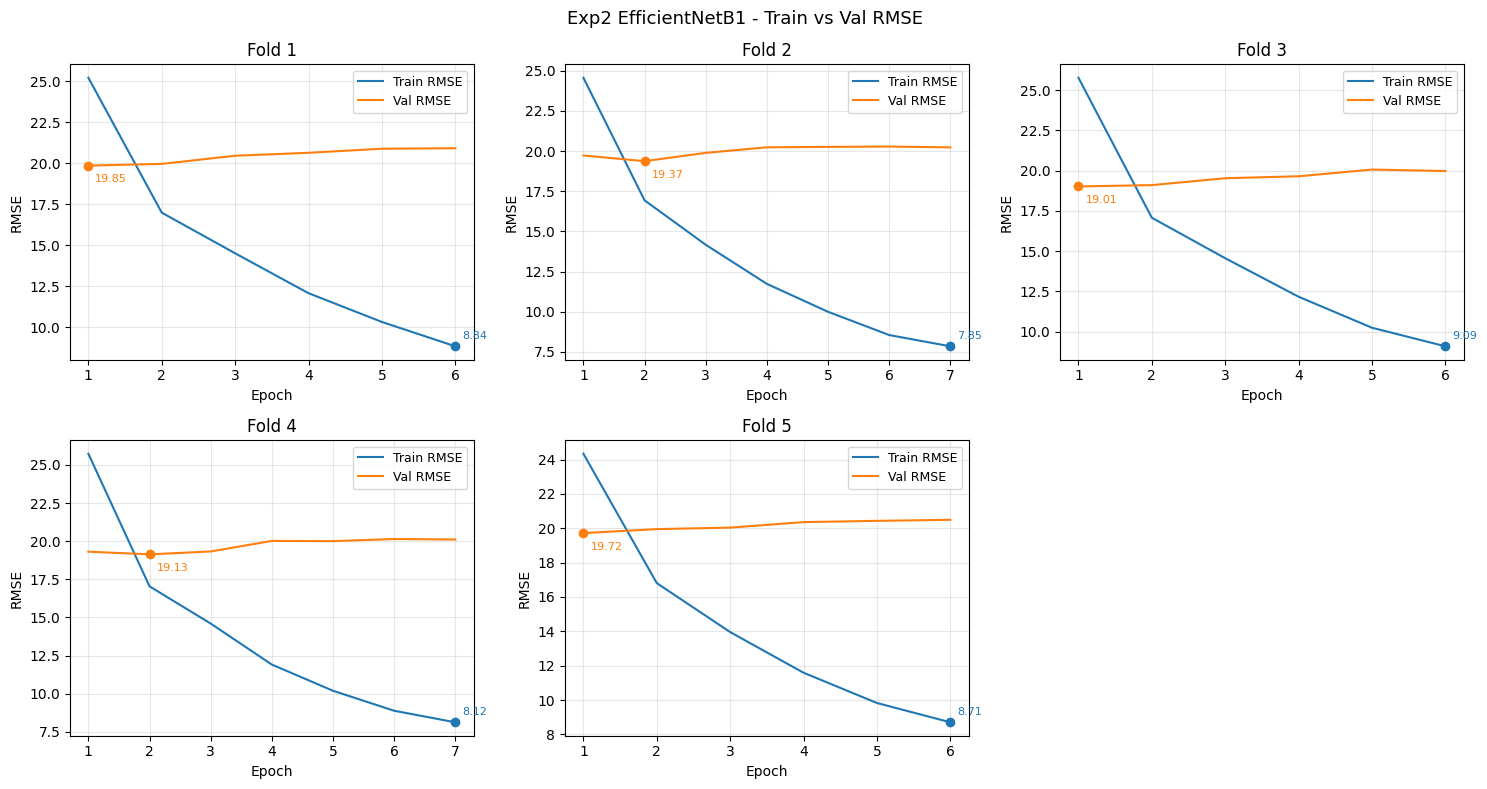

In [16]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp2 EfficientNetB1")

### Image backbone Frozen, Batch Norm Running Stats Also Frozen

In [19]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

# id2idx = {id_: i for i, id_ in enumerate(df["Id"].values)}
start_all = time.time()

for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
        freeze_backbone=True,
        BN_running_state_frozen=True
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp2_256_effB1_Freeze_BN_Running_stats: Fold 1 ===
[TRAIN BATCH 247] preds min=-3519950618624.0000 max=87.6514 mean=-140798017536.0000var=495602079758500052860928.0000
[TRAIN BATCH 247] loss=495602079758500052860928.0000
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=9074870208019870.0000 | ValRMSE: 3077950731714560.0000
[TRAIN BATCH 247] preds min=26.4749 max=55.2460 mean=36.3969var=49.5024
[TRAIN BATCH 247] loss=385.9723
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=150043452716733.1250 | ValRMSE: 43706480590848.0000
[TRAIN BATCH 247] preds min=-113294861926400.0000 max=61.9177 mean=-4531794477056.0000var=513429002566809045929295872.0000
[TRAIN BATCH 247] loss=513429039460297193348399104.0000
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=459389138862473.6875 | ValRMSE: 147274848010240.0000
[TRAIN BATCH 247] preds min=19.0901 max=49.1729 mean=35.0491var=77.2650
[TRAIN BATCH 247] loss=231.9321
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=581660570155119.2500 | ValRMSE: 371842330132480.0000
[TRAIN BATCH 247] 

### Reduce LR 

In [20]:
#current"lr": 2e-5,0.00002
cfg["lr"] = 2e-7 #0.0000002

In [21]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

# id2idx = {id_: i for i, id_ in enumerate(df["Id"].values)}
start_all = time.time()

for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
        freeze_backbone=True,
        BN_running_state_frozen=True
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


=== exp2_256_effB1_Freeze_BN_Running_stats: Fold 1 ===
[TRAIN BATCH 247] preds min=0.8704 max=264359378944.0000 mean=10574374912.0000var=2795435235679651495936.0000
[TRAIN BATCH 247] loss=2795435235679651495936.0000
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=1090042204050015.5000 | ValRMSE: 4959367061307392.0000
[TRAIN BATCH 247] preds min=-24.2376 max=36.4378 mean=22.6360var=185.6703
[TRAIN BATCH 247] loss=430.0257
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=983391571163293.7500 | ValRMSE: 412320719175680.0000
[TRAIN BATCH 247] preds min=3.2196 max=453346272.0000 mean=18133878.0000var=8220913686282240.0000
[TRAIN BATCH 247] loss=8220912075669504.0000
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=757735680972821.0000 | ValRMSE: 441143036739584.0000
[TRAIN BATCH 247] preds min=8.9896 max=56.5730 mean=35.2079var=96.2866
[TRAIN BATCH 247] loss=426.6532
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=1101377502782315.6250 | ValRMSE: 442109337272320.0000
[TRAIN BATCH 247] preds min=-31.1281 max=37301648359424.0000

In [22]:
cfg["lr"] =2e-5

### GradientClip

In [26]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

# id2idx = {id_: i for i, id_ in enumerate(df["Id"].values)}
start_all = time.time()

for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
        freeze_backbone=True,
        BN_running_state_frozen=True,
        gradient_clip=True
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


=== exp2_256_effB1_Freeze_BN_Running_stats: Fold 1 ===
[TRAIN BATCH 247] preds min=-5284071.0000 max=4235.0156 mean=-265703.0000var=1109126807552.0000
[TRAIN BATCH 247] loss=1135378038784.0000
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=823431926344954.3750 | ValRMSE: 342471409664.0000
[TRAIN BATCH 247] preds min=28.4708 max=29.0766 mean=28.7616var=0.0443
[TRAIN BATCH 247] loss=357.9674
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=44875936051941.1484 | ValRMSE: 113911055515648.0000
[TRAIN BATCH 247] preds min=42.5396 max=44.6235 mean=42.7650var=0.1593
[TRAIN BATCH 247] loss=534.2235
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=1974113411104080.2500 | ValRMSE: 29015461068800.0000
[TRAIN BATCH 247] preds min=45.3726 max=45.9839 mean=45.7320var=0.0254
[TRAIN BATCH 247] loss=418.0762
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=991557192293485.5000 | ValRMSE: 23668312768512.0000
[TRAIN BATCH 247] preds min=40.2774 max=42.9933 mean=41.0575var=0.4113
[TRAIN BATCH 247] loss=406.8233
Epoch 5/10 | Fold 1 | Train[MSE

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

# id2idx = {id_: i for i, id_ in enumerate(df["Id"].values)}
start_all = time.time()

for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
        freeze_backbone=True,
        BN_running_state_frozen=True,

    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


=== exp2_256_effB1_Freeze_BN_Running_stats: Fold 1 ===
